In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rahulvyasm/netflix-movies-and-tv-shows")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'netflix-movies-and-tv-shows' dataset.
Path to dataset files: /kaggle/input/netflix-movies-and-tv-shows


1.  **pandas** --> Data load aur manipulate karne ke liya
2.numpy --> Numerical operations ke liye
3.**mataplotlib** --> Basic visualization
4.**seaborn **--> Attractive Statistical Plot

In [32]:
import os # to see which file is inside it
os.listdir(path)

['netflix_titles.csv']

In [33]:
df=pd.read_csv(path + "/netflix_titles.csv", encoding='latin1')

In [34]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25'],
      dtype='object')

In [36]:
df.shape

(8809, 26)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8809 non-null   object 
 1   type          8809 non-null   object 
 2   title         8809 non-null   object 
 3   director      6175 non-null   object 
 4   cast          7984 non-null   object 
 5   country       7978 non-null   object 
 6   date_added    8799 non-null   object 
 7   release_year  8809 non-null   int64  
 8   rating        8805 non-null   object 
 9   duration      8806 non-null   object 
 10  listed_in     8809 non-null   object 
 11  description   8809 non-null   object 
 12  Unnamed: 12   0 non-null      float64
 13  Unnamed: 13   0 non-null      float64
 14  Unnamed: 14   0 non-null      float64
 15  Unnamed: 15   0 non-null      float64
 16  Unnamed: 16   0 non-null      float64
 17  Unnamed: 17   0 non-null      float64
 18  Unnamed: 18   0 non-null    

Remove unwanted columns


In [38]:
df= df.drop(columns=df.columns[df.columns.str.contains("Unnamed")])

In [39]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [40]:
df.isnull().sum()/len(df)*100

,0
show_id,0.000000
type,0.000000
title,0.000000
director,29.901237
cast,9.365422
country,9.433534
date_added,0.113520
release_year,0.000000
rating,0.045408
duration,0.034056


In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.nunique()

,0
show_id,8809
type,2
title,8806
director,4529
cast,7694
country,748
date_added,1768
release_year,75
rating,18
duration,220


In [43]:
df.describe()

,release_year
count,8809.000000
mean,2014.181292
std,8.818932
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2024.000000


In [44]:
df.describe(include='object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8809,8809,8809,6175,7984,7978,8799,8805,8806,8809,8809
unique,8809,2,8806,4529,7694,748,1768,18,220,516,8777
top,s8809,Movie,22-Jul,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6132,2,19,19,2819,109,3208,1794,362,4


In [45]:
numerical_df = df.select_dtypes(include=np.number)
categorical_df = df.select_dtypes(exclude=np.number)


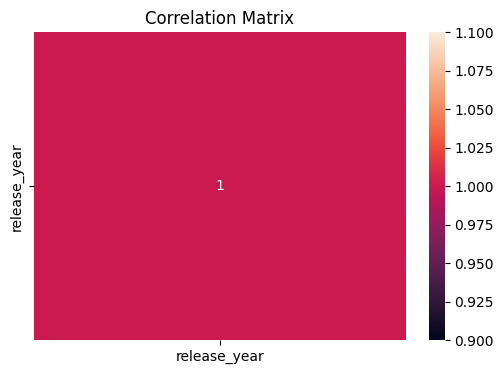

In [46]:
plt.figure(figsize=(6,4))
sns.heatmap(numerical_df.corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()


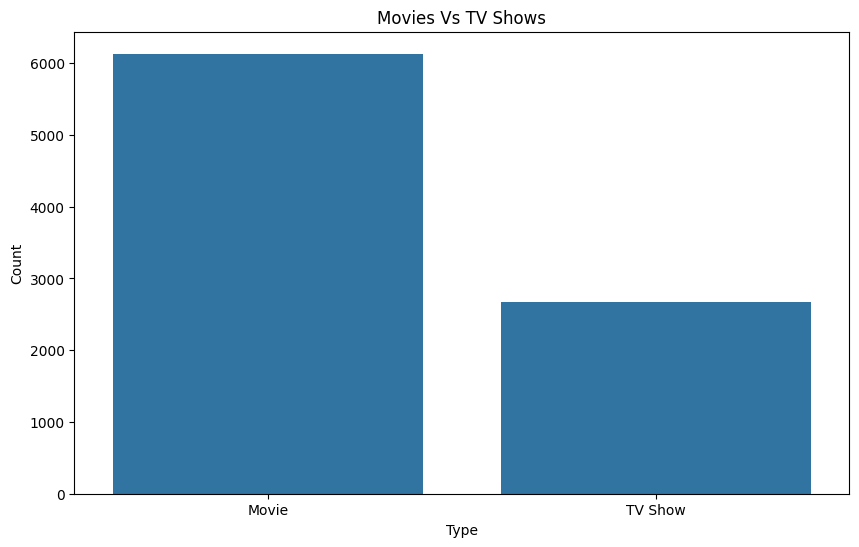

In [47]:
plt.figure(figsize=(10,6))
sns.countplot(x='type', data=df)
plt.title('Distribution of Movie and TV Shows')
plt.title("Movies Vs TV Shows")
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

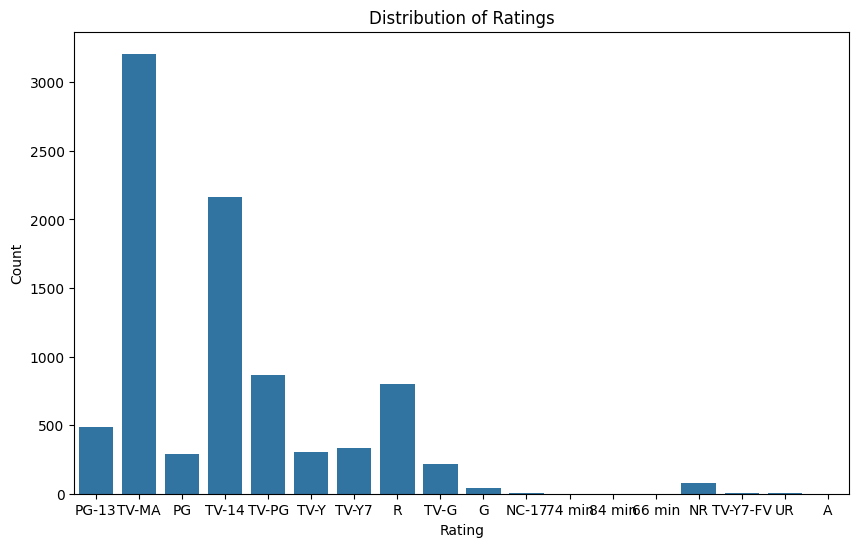

In [48]:
plt.figure(figsize=(10,6))
sns.countplot(x='rating', data=df)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

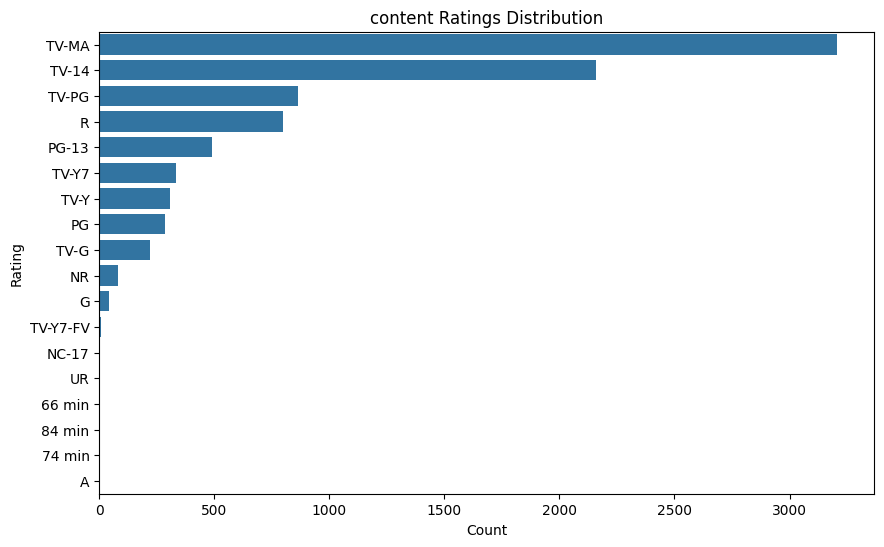

In [49]:
plt.figure(figsize=(10,6))
sns.countplot(
    y = 'rating',
    data = df,
    order = df['rating'].value_counts().index
)
plt.title('content Ratings Distribution')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()

### 1. Handling Missing Values

Based on the `df.isnull().sum()` output, we have missing values in 'director', 'cast', 'country', 'date_added', 'rating', and 'duration'.

- For 'director', 'cast', and 'country', I'll fill missing values with 'Unknown' as these are categorical and 'Unknown' is a meaningful category.
- For 'date_added', 'rating', and 'duration', the number of missing values is very small (less than 1%), so dropping these rows will have a minimal impact on the dataset and will simplify further analysis.

In [50]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

# Drop rows with remaining missing values (date_added, rating, duration)
df.dropna(inplace=True)

print("Missing values after handling:")
display(df.isnull().sum())

Missing values after handling:


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


### 2. Analyzing Content Added Over Time

Let's convert the `date_added` column to datetime objects and extract the year and month to see trends in content additions to Netflix.

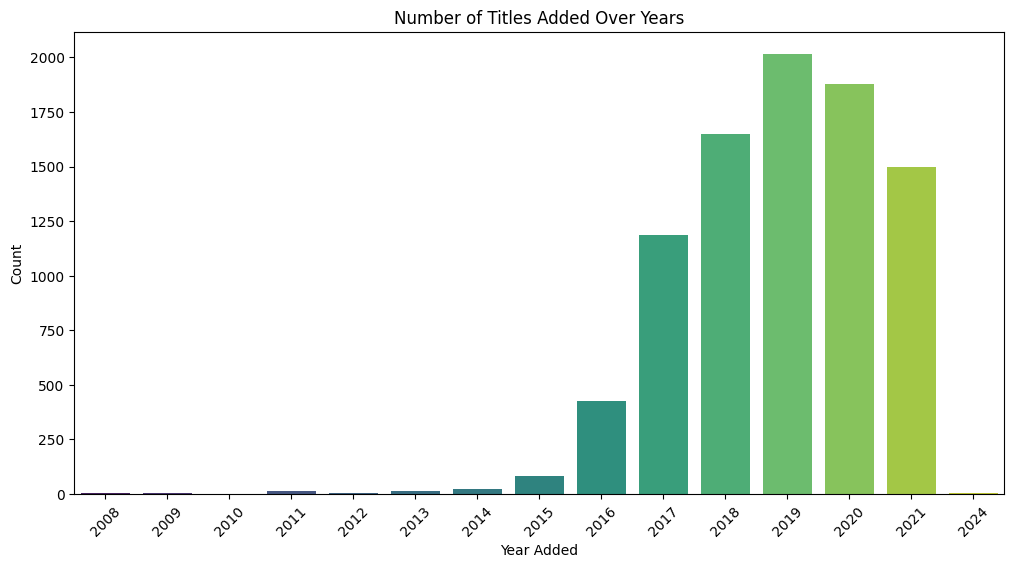

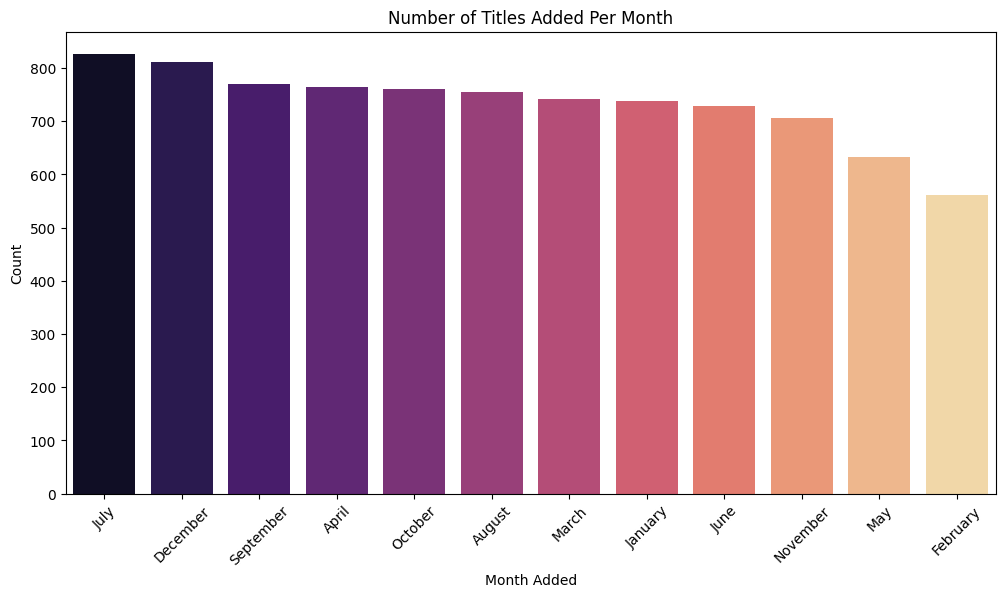

In [52]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Drop rows where date_added could not be parsed (became NaT)
df.dropna(subset=['date_added'], inplace=True)

# Plotting content added over years
plt.figure(figsize=(12, 6))
sns.countplot(x='year_added', data=df, palette='viridis')
plt.title('Number of Titles Added Over Years')
plt.xlabel('Year Added')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Plotting content added per month (overall)
plt.figure(figsize=(12, 6))
sns.countplot(x='month_added', data=df, order=df['month_added'].value_counts().index, palette='magma')
plt.title('Number of Titles Added Per Month')
plt.xlabel('Month Added')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Task
Perform a comprehensive Exploratory Data Analysis (EDA) on the Netflix movies and TV shows dataset. The EDA should cover the following aspects:

1.  **Analyze Content Type Distribution**: Visualize the distribution of 'Movie' versus 'TV Show' in the dataset to understand the proportion of each content type on Netflix.
2.  **Analyze Top Countries**: Identify the top 10 countries with the most content on Netflix and visualize their distribution.
3.  **Analyze Top Directors**: Determine the top 10 directors with the most titles on Netflix and visualize them. Exclude 'Unknown' directors.
4.  **Analyze Top Genres**: Extract and count the most frequent genres ('listed_in') to understand content categories. Visualize the top 10 genres.
5.  **Analyze Content Duration**: Clean and transform the 'duration' column to separate movie durations (in minutes) and TV show seasons. Visualize the distribution of movie durations and the distribution of TV show seasons.
6.  **Final Task**: Summarize all the key insights and findings from the comprehensive Exploratory Data Analysis.

## Analyze Content Type Distribution

### Subtask:
Visualize the distribution of 'Movie' versus 'TV Show' in the dataset to understand the proportion of each content type on Netflix.


## Analyze Top Countries

### Subtask:
Identify the top 10 countries with the most content on Netflix and visualize their distribution.


**Reasoning**:
I need to extract and count individual countries, handle multiple countries in a single entry, filter out 'Unknown' entries, and then visualize the top 10. The first step involves processing the 'country' column.



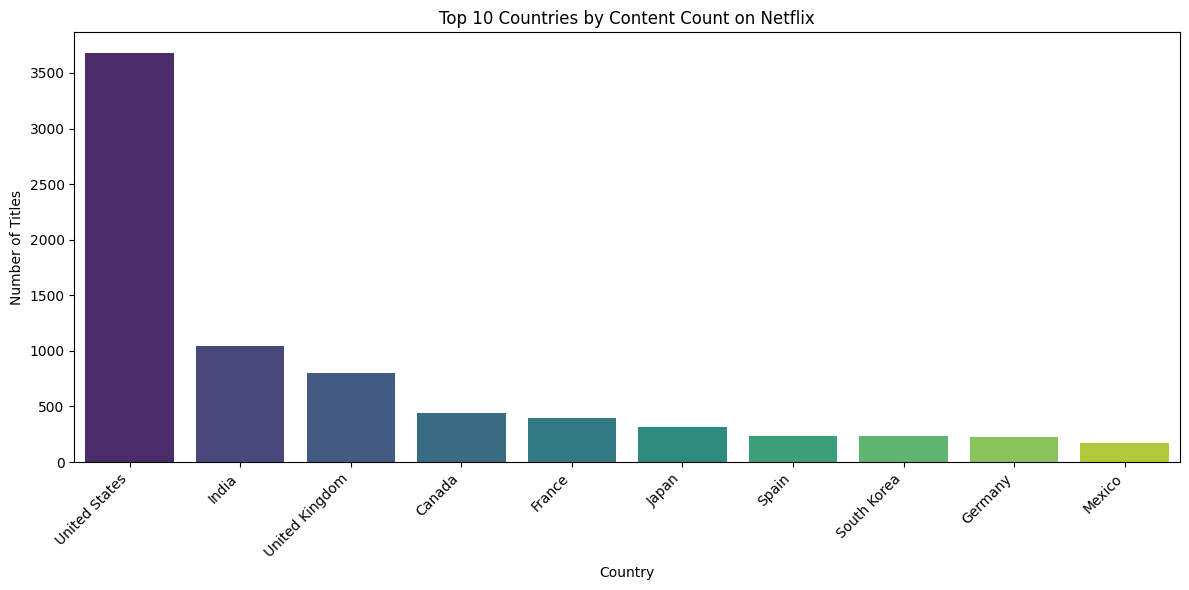

In [53]:
country_counts = df['country'].str.split(', ', expand=True).stack()
country_counts = country_counts[country_counts != 'Unknown']
top_10_countries = country_counts.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='viridis')
plt.title('Top 10 Countries by Content Count on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Analyze Top Directors

### Subtask:
Determine the top 10 directors with the most titles on Netflix and visualize their distribution, excluding 'Unknown' directors.


**Reasoning**:
The first step for 'Analyze Top Directors' involves processing the 'director' column to extract individual names, filter out 'Unknown' directors, count their titles, and prepare the data for visualization. This will be followed by generating the bar chart.



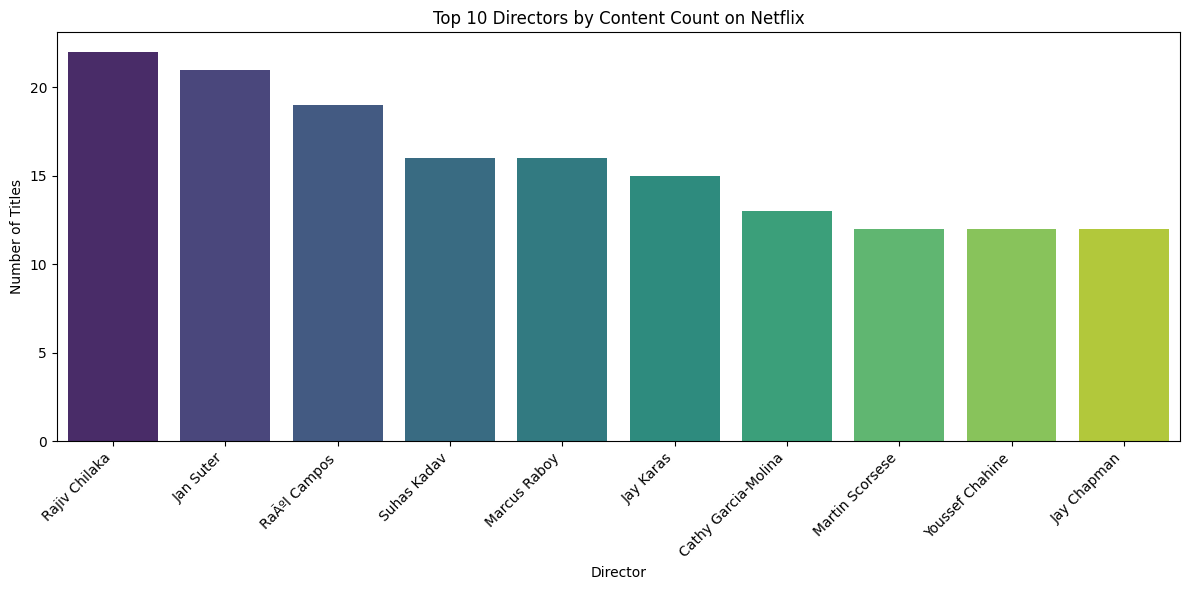

In [54]:
director_counts = df['director'].str.split(', ', expand=True).stack()
director_counts = director_counts[director_counts != 'Unknown']
top_10_directors = director_counts.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_directors.index, y=top_10_directors.values, palette='viridis')
plt.title('Top 10 Directors by Content Count on Netflix')
plt.xlabel('Director')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Analyze Top Genres

### Subtask:
Extract and count the most frequent genres ('listed_in') to understand content categories. Visualize the top 10 genres.


**Reasoning**:
This step processes the 'listed_in' column to split multiple genres into individual entries, counts their frequencies, and selects the top 10 to prepare for visualization. This directly addresses the first part of the subtask instructions.



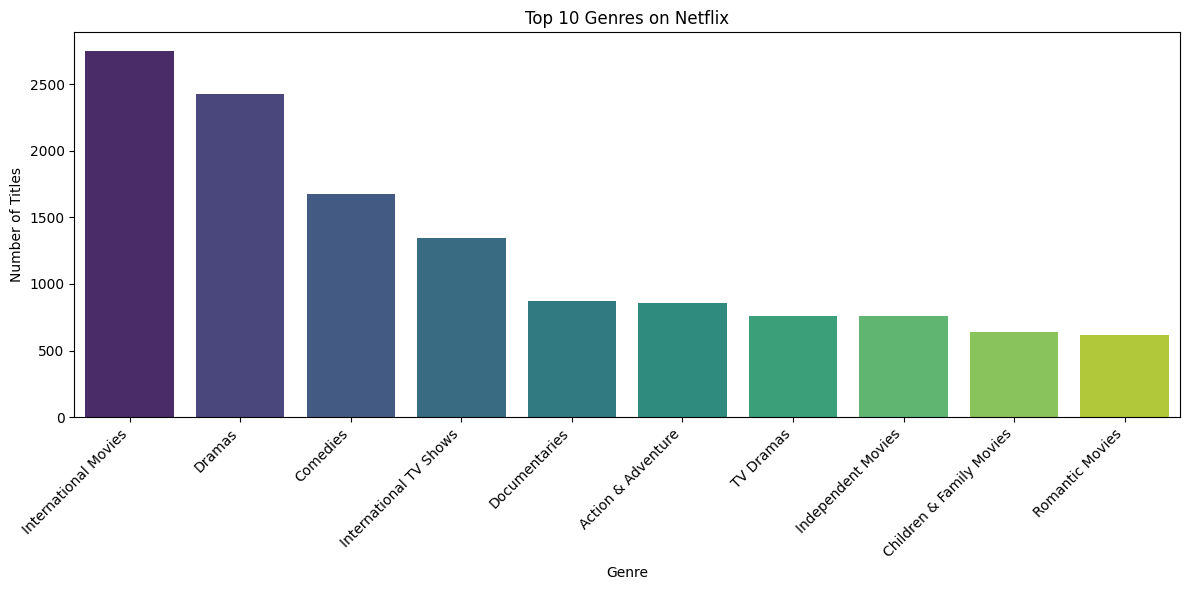

In [55]:
genre_counts = df['listed_in'].str.split(', ', expand=True).stack()
top_10_genres = genre_counts.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_genres.index, y=top_10_genres.values, palette='viridis')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Analyze Content Duration

### Subtask:
Clean and transform the 'duration' column to separate movie durations (in minutes) and TV show seasons. Visualize the distribution of movie durations and the distribution of TV show seasons.


**Reasoning**:
Separate the DataFrame into two based on content 'type': one for 'Movie' and one for 'TV Show'.



In [56]:
movies_df = df[df['type'] == 'Movie'].copy()
tv_shows_df = df[df['type'] == 'TV Show'].copy()

print("Movies DataFrame head:")
display(movies_df.head())
print("\nTV Shows DataFrame head:")
display(tv_shows_df.head())

Movies DataFrame head:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, JosÃ© Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,September
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,September
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021,September
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis NiewÃ¶hner, Milan Peschel,...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021,September



TV Shows DataFrame head:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021,September


**Reasoning**:
Extract the numerical duration for movies from the 'duration' column and convert it to an integer, then display the first few rows and information about the modified column to verify the cleaning process.



In [57]:
movies_df['duration'] = movies_df['duration'].str.replace(' min', '').astype(int)

print("Movies DataFrame with cleaned duration:")
display(movies_df.head())
display(movies_df['duration'].info())

Movies DataFrame with cleaned duration:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm...",2021,September
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, JosÃ© Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,September
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,September
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021,September
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis NiewÃ¶hner, Milan Peschel,...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127,"Dramas, International Movies",After most of her family is murdered in a terr...,2021,September


<class 'pandas.core.series.Series'>
Index: 6127 entries, 0 to 8808
Series name: duration
Non-Null Count  Dtype
--------------  -----
6127 non-null   int64
dtypes: int64(1)
memory usage: 95.7 KB


None

**Reasoning**:
Extract the numerical duration for TV shows from the 'duration' column and convert it to an integer, then display the first few rows and information about the modified column to verify the cleaning process.



In [58]:
tv_shows_df['duration'] = tv_shows_df['duration'].str.replace(' Seasons?', '', regex=True).astype(int)

print("TV Shows DataFrame with cleaned duration:")
display(tv_shows_df.head())
display(tv_shows_df['duration'].info())

TV Shows DataFrame with cleaned duration:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021,September


<class 'pandas.core.series.Series'>
Index: 2665 entries, 1 to 8807
Series name: duration
Non-Null Count  Dtype
--------------  -----
2665 non-null   int64
dtypes: int64(1)
memory usage: 41.6 KB


None

**Reasoning**:
Visualize the distribution of movie durations using a histogram to understand the spread of movie lengths.



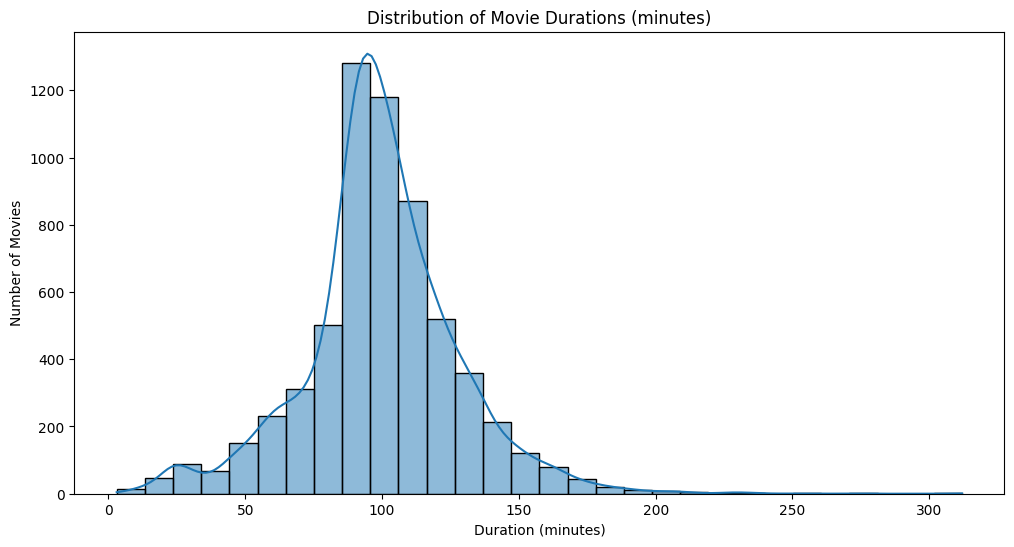

In [59]:
plt.figure(figsize=(12, 6))
sns.histplot(movies_df['duration'], bins=30, kde=True)
plt.title('Distribution of Movie Durations (minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.show()

**Reasoning**:
Visualize the distribution of TV show seasons using a count plot to understand the spread of seasons for TV shows.



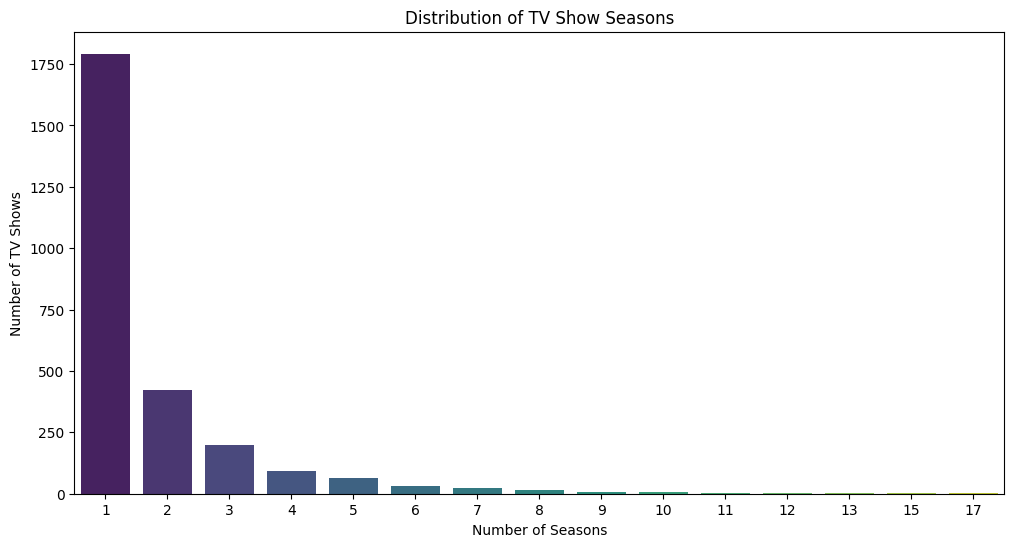

In [60]:
plt.figure(figsize=(12, 6))
sns.countplot(x='duration', data=tv_shows_df, palette='viridis')
plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.show()

## Final Task

### Subtask:
Summarize all the key insights and findings from the comprehensive Exploratory Data Analysis.
